# Análisis de sensibilidad a la rugosidad — HEC-RAS

Caso de estudio: **Río Besaya — Corrales de Buelna**  
Modelo: HEC-RAS 6.6 2D (USACE), resolución 5 m, T=500 años

Se analizan 1.000 simulaciones con distintas combinaciones de Manning.

**Bugs corregidos respecto al análisis original:**
- Los TIFFs se cargan en orden numérico (`load_flood_ensemble`) — no léxico.
- La estadística espacial usa `mean(dim=['x','y'])` — no secuencial.
- El área inundada usa factor `1e-6` para m² → km² — no `10e-6`.
- El umbral de 0.05 m se aplica al cargar (coherente con SFINCS).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pyhydra.modeling.hydraulic.sensitivity import (
    load_flood_ensemble,
    build_manning_ensemble,
    flooded_area,
    spatial_stats,
    manning_flood_regression,
)

## Rutas — ajustar según el entorno

In [2]:
BASE_DIR         = Path("/Volumes/My Passport 2/COPIA_IH/E/Rugosidades_UCLM")
RESULTS_DIR      = BASE_DIR / "HEC_RAS/results"
COMBINATIONS_DIR = BASE_DIR / "Ejemplo_Besaya/nsim_rugos"
MANNING_TIF      = BASE_DIR / "Ejemplo_Besaya/manning.tif"

# HEC-RAS cubre todo el dominio; excluir zona aguas abajo con poca inundación
LAT_MIN = 4_791_370.53   # coordenada Y mínima (EPSG:25830) para filtrar puntos

CELL_AREA_M2 = 25.0
THRESHOLD    = 0.05

## 1 · Cargar ensemble de resultados HEC-RAS

In [3]:
flood = load_flood_ensemble(
    results_dir=str(RESULTS_DIR),
    pattern="hamax_sim_*.tif",
    threshold=THRESHOLD,
)
print(f"Ensemble HEC-RAS: {flood.dims} → shape {flood.shape}")
print(f"Simulaciones: {flood.simulation.values[[0, 1, 2, -2, -1]]}")

Ensemble HEC-RAS: ('simulation', 'y', 'x') → shape (1000, 1201, 679)
Simulaciones: [  0   1   2 998 999]


## 2 · Cargar ensemble de rugosidad de Manning

In [4]:
sim_numbers = flood.simulation.values.tolist()

manning = build_manning_ensemble(
    raster_path=str(MANNING_TIF),
    combinations_dir=str(COMBINATIONS_DIR),
    simulation_numbers=sim_numbers,
)
print(f"Ensemble Manning: {manning.dims} → shape {manning.shape}")

Ensemble Manning: ('simulation', 'y', 'x') → shape (1000, 600, 339)


## 3 · Estadísticos espaciales por simulación

In [5]:
calado_stats  = spatial_stats(flood)
manning_stats = spatial_stats(manning)
areas_m2      = flooded_area(flood, cell_area_m2=CELL_AREA_M2, threshold=THRESHOLD)

print(calado_stats.describe().round(3))

           mean    median       std       max
count  1000.000  1000.000  1000.000  1000.000
mean      1.220     0.981     0.947     6.350
std       0.080     0.051     0.085     0.201
min       1.053     0.853     0.780     4.979
25%       1.152     0.938     0.881     6.253
50%       1.218     0.980     0.946     6.351
75%       1.297     1.012     1.014     6.431
max       1.930     1.517     1.902     9.457


## 4 · Distribuciones de resultados entre simulaciones

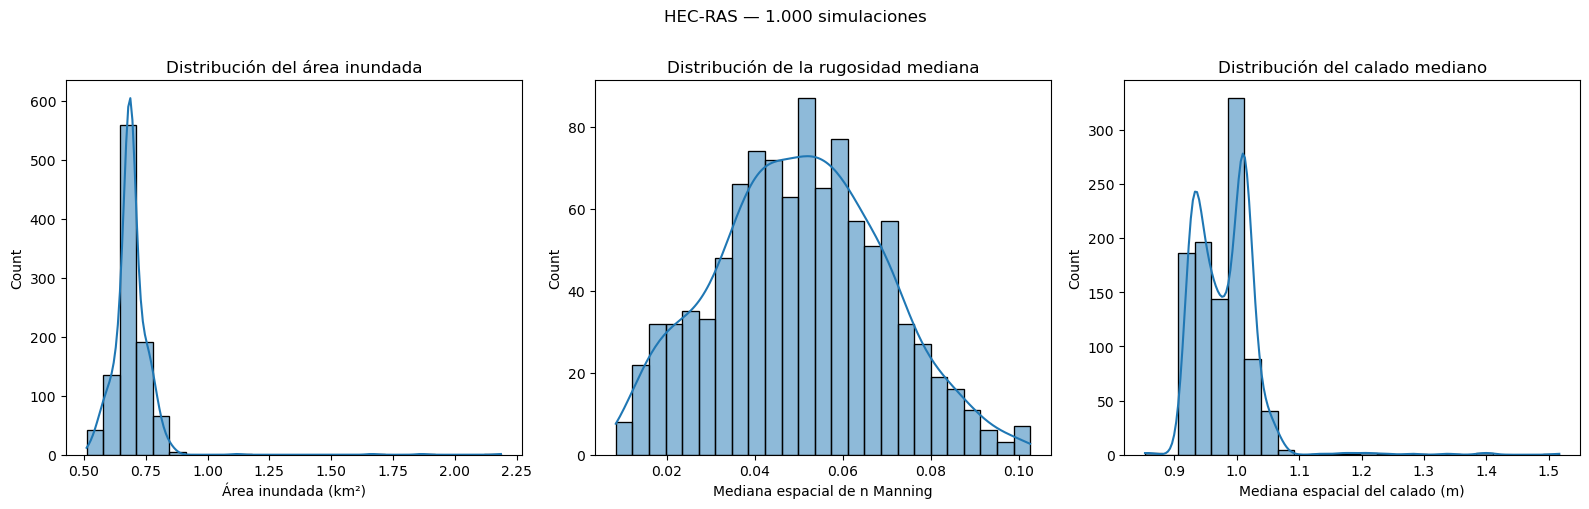

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(areas_m2 * 1e-6, bins=25, kde=True, ax=axes[0])
axes[0].set_xlabel("Área inundada (km²)")
axes[0].set_title("Distribución del área inundada")

sns.histplot(manning_stats["median"], bins=25, kde=True, ax=axes[1])
axes[1].set_xlabel("Mediana espacial de n Manning")
axes[1].set_title("Distribución de la rugosidad mediana")

sns.histplot(calado_stats["median"], bins=25, kde=True, ax=axes[2])
axes[2].set_xlabel("Mediana espacial del calado (m)")
axes[2].set_title("Distribución del calado mediano")

plt.suptitle("HEC-RAS — 1.000 simulaciones", y=1.01)
plt.tight_layout()
plt.show()

## 5 · Regresión rugosidad ↔ calado y área inundada

In [7]:
reg = manning_flood_regression(
    flood_ensemble=flood,
    manning_ensemble=manning,
    cell_area_m2=CELL_AREA_M2,
    threshold=THRESHOLD,
)
reg.head()

,manning_mean,manning_median,depth_mean,depth_median,flooded_area_m2
simulation,,,,,
0,0.055682,0.048122,1.114162,0.957298,651675.0
1,0.065136,0.054543,1.185237,0.995060,639850.0
2,0.054310,0.054742,1.159505,1.030598,570250.0
3,0.049771,0.048058,1.253807,0.969049,710000.0
4,0.070618,0.050504,1.266569,0.965141,758775.0


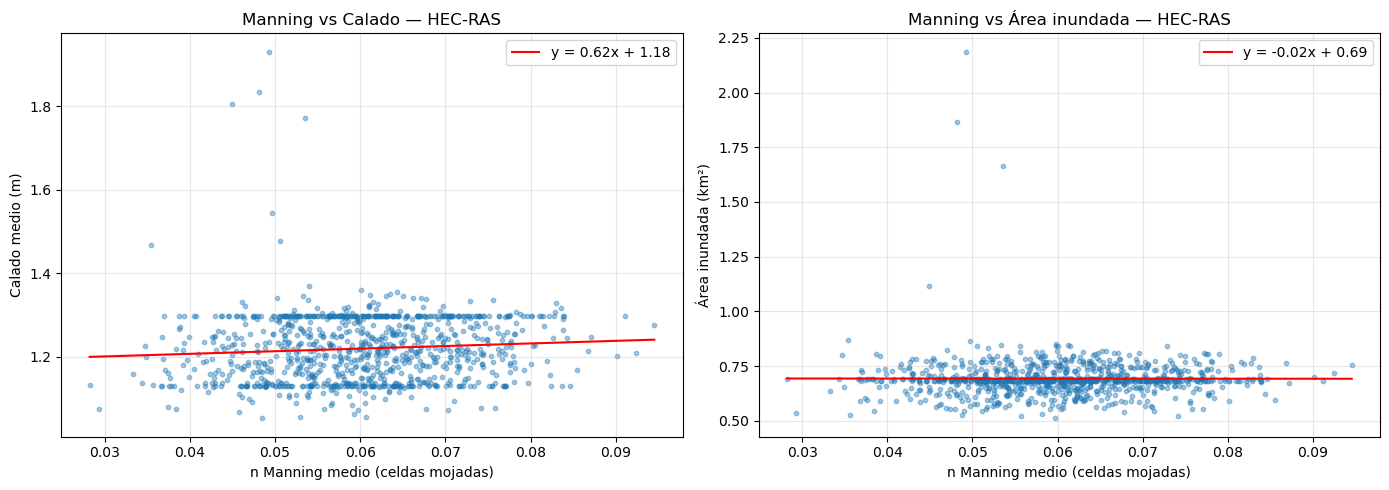

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(reg["manning_mean"], reg["depth_mean"], alpha=0.4, s=10)
coef = np.polyfit(reg["manning_mean"].dropna(), reg["depth_mean"].dropna(), 1)
x_line = np.linspace(reg["manning_mean"].min(), reg["manning_mean"].max(), 100)
ax.plot(x_line, np.polyval(coef, x_line), "r-",
        label=f"y = {coef[0]:.2f}x + {coef[1]:.2f}")
ax.set_xlabel("n Manning medio (celdas mojadas)")
ax.set_ylabel("Calado medio (m)")
ax.set_title("Manning vs Calado — HEC-RAS")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(reg["manning_mean"], reg["flooded_area_m2"] * 1e-6, alpha=0.4, s=10)
valid = reg[["manning_mean", "flooded_area_m2"]].dropna()
coef2 = np.polyfit(valid["manning_mean"], valid["flooded_area_m2"] * 1e-6, 1)
ax.plot(x_line, np.polyval(coef2, x_line), "r-",
        label=f"y = {coef2[0]:.2f}x + {coef2[1]:.2f}")
ax.set_xlabel("n Manning medio (celdas mojadas)")
ax.set_ylabel("Área inundada (km²)")
ax.set_title("Manning vs Área inundada — HEC-RAS")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6 · Scatter 3D: calado × área × rugosidad

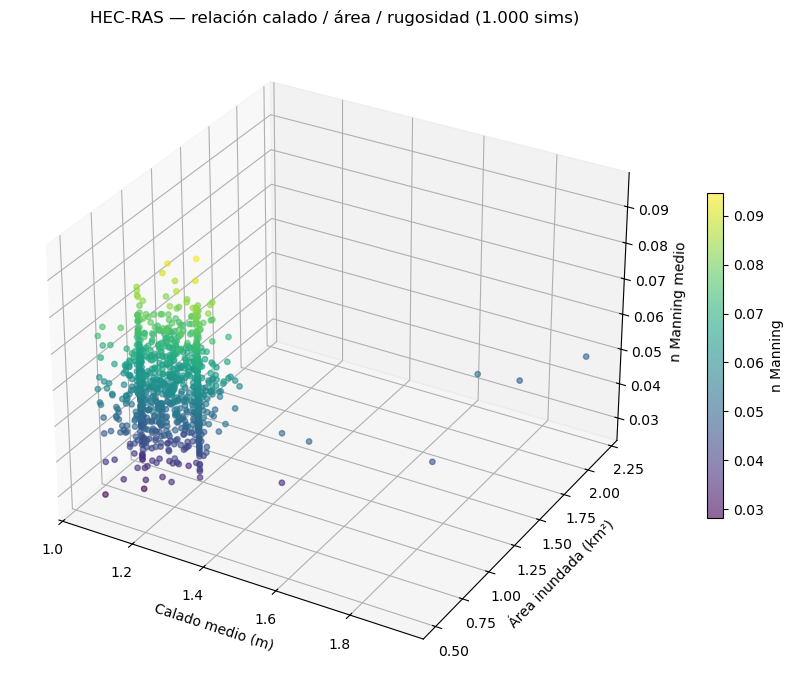

In [9]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    reg["depth_mean"],
    reg["flooded_area_m2"] * 1e-6,
    reg["manning_mean"],
    c=reg["manning_mean"],
    cmap="viridis",
    alpha=0.6,
    s=15,
)
ax.set_xlabel("Calado medio (m)")
ax.set_ylabel("Área inundada (km²)")
ax.set_zlabel("n Manning medio")
ax.set_title("HEC-RAS — relación calado / área / rugosidad (1.000 sims)")
fig.colorbar(sc, ax=ax, label="n Manning", shrink=0.5)
plt.tight_layout()
plt.show()

## 7 · Simulación con mayor calado medio

Simulación con mayor calado medio: sim_29
mean      1.930
median    1.337
std       1.902
max       9.457
Name: 29, dtype: float32


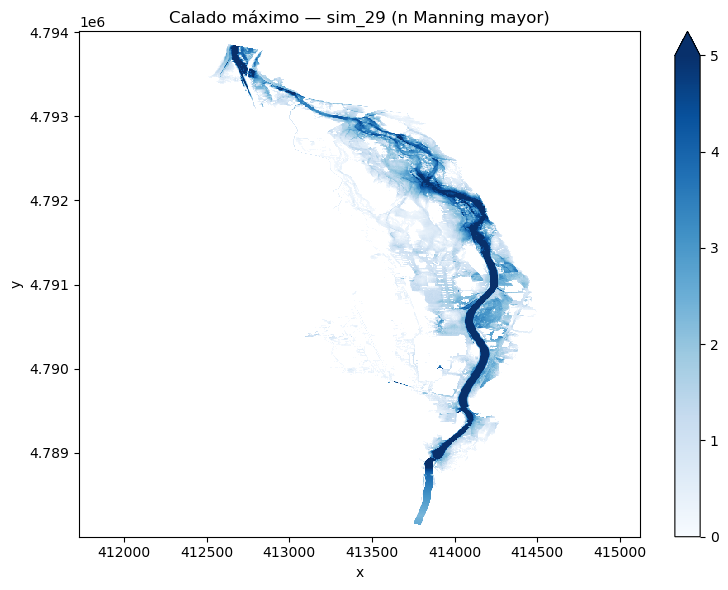

In [10]:
sim_max = int(calado_stats["mean"].idxmax())
print(f"Simulación con mayor calado medio: sim_{sim_max}")
print(calado_stats.loc[sim_max].round(3))

fig, ax = plt.subplots(figsize=(8, 6))
flood.sel(simulation=sim_max).plot(ax=ax, cmap="Blues", vmin=0, vmax=5)
ax.set_title(f"Calado máximo — sim_{sim_max} (n Manning mayor)")
plt.tight_layout()
plt.show()

## 8 · Guardar tabla de resultados

In [11]:
results = reg.copy()
results["flooded_area_km2"] = results["flooded_area_m2"] * 1e-6
results.drop(columns="flooded_area_m2", inplace=True)

out_csv = Path("hecras_sensitivity_results.csv")
results.to_csv(out_csv)
print(f"Guardado: {out_csv.resolve()}")

Guardado: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/notebooks/modeling/hydraulic/manning_sensitivity/hecras_sensitivity_results.csv
